# Lab 8: Introducción al deep learning con PyTorch

## Sección 1. Redes multicapa con `nn.Module`

Resolver XOR con una MLP, comparar el efecto de quitar la activación y revisar los parámetros de una red multicapa.

Se trabaja en CPU con semilla 42. Los comentarios de resultados se basan en las salidas guardadas de esta ejecución.

### Preparación

Se requieren PyTorch 2.x, NumPy y Matplotlib. Si falta alguna dependencia en el kernel seleccionado, descomenta y ejecuta la siguiente celda; luego reinicia el kernel.

In [1]:
# %pip install "torch>=2,<3" numpy matplotlib

In [3]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Dispositivo: CPU")

PyTorch: 2.14.1
NumPy: 2.5.3
Dispositivo: CPU


### 1.1. Datos XOR y definición de la MLP

La red tiene dos entradas, una capa oculta de 8 neuronas con `tanh` y una salida. La salida entrega logits para `BCEWithLogitsLoss`; la probabilidad se obtiene con `sigmoid` al evaluar.

In [4]:
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

print(" x1  x2 | XOR")
for entrada, objetivo in zip(X, y):
    print(f" {int(entrada[0])}   {int(entrada[1])}  |  {int(objetivo.item())}")


class MLP(nn.Module):
    def __init__(self, con_activacion=True):
        super().__init__()
        self.oculta = nn.Linear(2, 8)
        self.activacion = nn.Tanh() if con_activacion else nn.Identity()
        self.salida = nn.Linear(8, 1)

    def forward(self, x):
        return self.salida(self.activacion(self.oculta(x)))


torch.manual_seed(42)
modelo_xor = MLP(con_activacion=True)
modelo_lineal = MLP(con_activacion=False)
# Ambos modelos parten de exactamente los mismos pesos y sesgos.
modelo_lineal.load_state_dict(copy.deepcopy(modelo_xor.state_dict()))
print("\nMLP con activación:\n", modelo_xor)
print("\nMLP sin activación:\n", modelo_lineal)

 x1  x2 | XOR
 0   0  |  0
 0   1  |  1
 1   0  |  1
 1   1  |  0

MLP con activación:
 MLP(
  (oculta): Linear(in_features=2, out_features=8, bias=True)
  (activacion): Tanh()
  (salida): Linear(in_features=8, out_features=1, bias=True)
)

MLP sin activación:
 MLP(
  (oculta): Linear(in_features=2, out_features=8, bias=True)
  (activacion): Identity()
  (salida): Linear(in_features=8, out_features=1, bias=True)
)


### 1.2. Entrenamiento y comparación

Se usa Adam con tasa 0.03 y hasta 3000 épocas. La MLP se detiene cuando clasifica correctamente las cuatro entradas y su pérdida es menor que 0.01. La versión sin activación recibe el mismo número de actualizaciones. El umbral de clasificación es 0.5.

In [5]:
def entrenar(modelo, epocas, detener_al_resolver=False):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=0.03)
    criterio = nn.BCEWithLogitsLoss()
    historial = {"perdida": [], "exactitud": []}
    modelo.train()

    for epoca in range(epocas):
        optimizador.zero_grad()
        logits = modelo(X)
        perdida = criterio(logits, y)
        perdida.backward()
        optimizador.step()

        # Registrar pérdida y exactitud después de la misma actualización.
        with torch.no_grad():
            logits_actuales = modelo(X)
            perdida_actual = criterio(logits_actuales, y).item()
            predicciones = (torch.sigmoid(logits_actuales) >= 0.5).float()
            exactitud = (predicciones == y).float().mean().item()

        historial["perdida"].append(perdida_actual)
        historial["exactitud"].append(exactitud)
        if detener_al_resolver and exactitud == 1.0 and perdida_actual < 0.01:
            break

    return historial


historial_xor = entrenar(modelo_xor, epocas=3000, detener_al_resolver=True)
historial_lineal = entrenar(modelo_lineal, epocas=len(historial_xor["perdida"]))

for nombre, historial in [("MLP con tanh", historial_xor),
                          ("MLP sin activación", historial_lineal)]:
    print(f"{nombre}: épocas={len(historial['perdida'])}, "
          f"pérdida={historial['perdida'][-1]:.6f}, "
          f"exactitud={historial['exactitud'][-1]:.0%}")

assert historial_xor["exactitud"][-1] == 1.0, "La MLP aún no resolvió XOR; revisa la ejecución."
assert historial_lineal["exactitud"][-1] < 1.0, "Revisa los datos y el modelo sin activación."

MLP con tanh: épocas=96, pérdida=0.009820, exactitud=100%
MLP sin activación: épocas=96, pérdida=0.693147, exactitud=50%


Entrada | Real | P(1) tanh | Pred. tanh | P(1) lineal | Pred. lineal
(0, 0)  |  0   |  0.004317 |     0      |   0.499901  |      0
(0, 1)  |  1   |  0.984623 |     1      |   0.499673  |      0
(1, 0)  |  1   |  0.991211 |     1      |   0.499811  |      0
(1, 1)  |  0   |  0.010572 |     0      |   0.499582  |      0


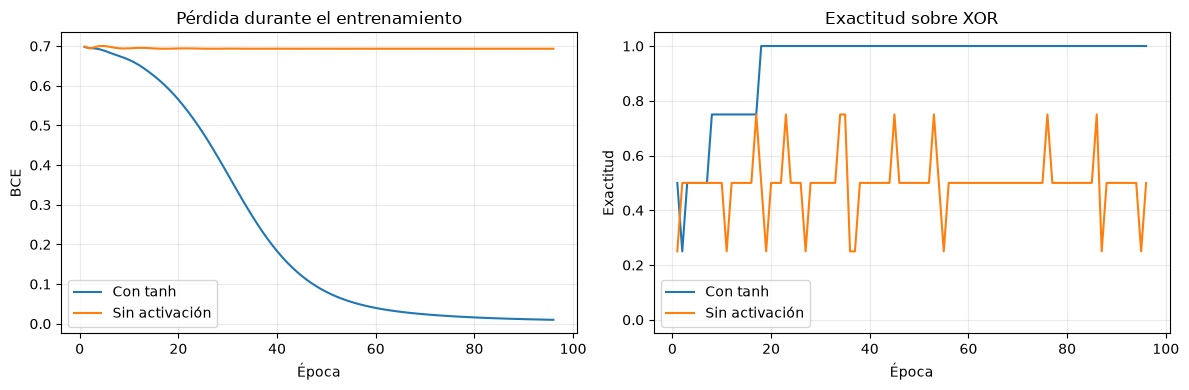

In [6]:
def evaluar(modelo):
    modelo.eval()
    with torch.no_grad():
        probabilidades = torch.sigmoid(modelo(X)).squeeze(1)
        predicciones = (probabilidades >= 0.5).long()
    return probabilidades, predicciones


prob_xor, pred_xor = evaluar(modelo_xor)
prob_lineal, pred_lineal = evaluar(modelo_lineal)
print("Entrada | Real | P(1) tanh | Pred. tanh | P(1) lineal | Pred. lineal")
for i in range(len(X)):
    entrada = tuple(int(v) for v in X[i])
    print(f"{entrada}  |  {int(y[i].item())}   |  {prob_xor[i].item():.6f} |"
          f"     {pred_xor[i].item()}      |   {prob_lineal[i].item():.6f}  |"
          f"      {pred_lineal[i].item()}")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for nombre, historial in [("Con tanh", historial_xor), ("Sin activación", historial_lineal)]:
    epocas = np.arange(1, len(historial["perdida"]) + 1)
    ejes[0].plot(epocas, historial["perdida"], label=nombre)
    ejes[1].plot(epocas, historial["exactitud"], label=nombre)
ejes[0].set(title="Pérdida durante el entrenamiento", xlabel="Época", ylabel="BCE")
ejes[1].set(title="Exactitud sobre XOR", xlabel="Época", ylabel="Exactitud", ylim=(-0.05, 1.05))
for eje in ejes:
    eje.legend()
    eje.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Resultados del entrenamiento

La MLP con `tanh` terminó el entrenamiento en **96 épocas**, con una pérdida de **0.009820** y **100% de exactitud** sobre las cuatro entradas de XOR. La gráfica muestra que alcanzó el 100% antes de terminar; las actualizaciones posteriores siguieron reduciendo la pérdida hasta cumplir el criterio de parada de menos de 0.01.

| Modelo | Épocas | Pérdida final (BCE) | Exactitud final |
|---|---:|---:|---:|
| MLP con `tanh` | 96 | 0.009820 | 100% |
| MLP sin activación oculta | 96 | 0.693147 | 50% |

Con `tanh`, las probabilidades de la clase 1 fueron **0.004317** para `(0, 0)` y **0.010572** para `(1, 1)`, mientras que para `(0, 1)` y `(1, 0)` fueron **0.984623** y **0.991211**. Por tanto, el umbral de 0.5 separa correctamente los cuatro casos y las probabilidades quedan próximas a sus etiquetas reales.

La red sin activación terminó prediciendo **0 para las cuatro entradas**, con probabilidades entre **0.499582 y 0.499901**. Solo acertó los dos casos cuya etiqueta era 0. Su pérdida de 0.693147 es aproximadamente ln(2), el valor de la entropía cruzada binaria cuando se asigna una probabilidad de 0.5. Las oscilaciones de exactitud durante el entrenamiento se explican por pequeños cambios de las probabilidades alrededor del umbral; no representan una solución estable de XOR.

Ambos modelos partieron de los mismos pesos y sesgos, utilizaron el mismo optimizador y recibieron el mismo número de actualizaciones. La diferencia observada está en la activación de la capa oculta. La exactitud reportada corresponde a los cuatro puntos usados para entrenar, que abarcan la tabla de verdad completa de XOR; no mide generalización a otros datos.

### 1.3. Fronteras de decisión

Los colores representan la probabilidad de la clase 1. La línea negra marca el umbral 0.5 y las etiquetas de los puntos muestran los valores reales de XOR.

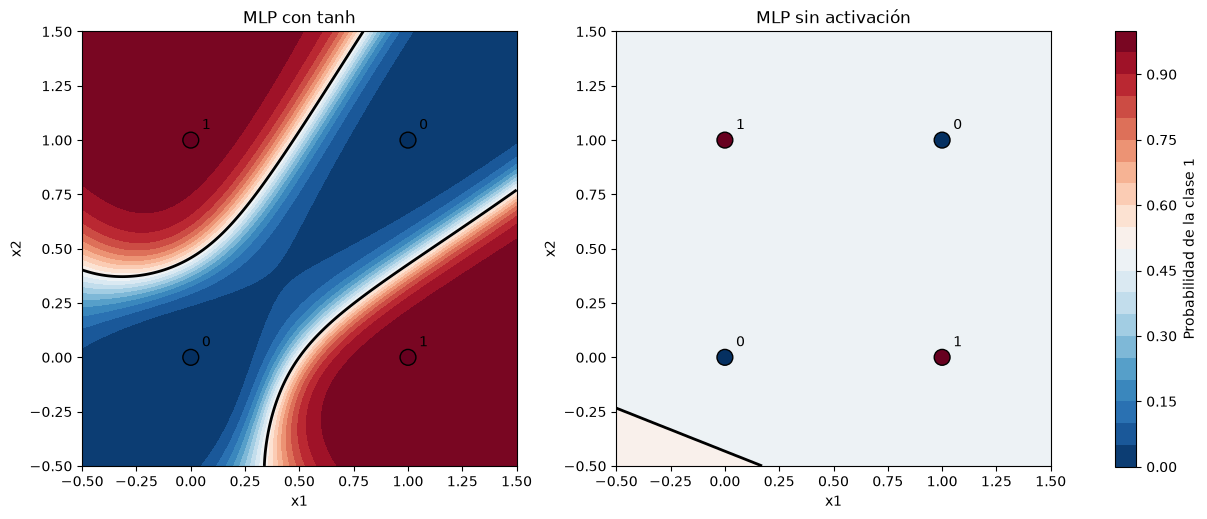

In [7]:
valores = np.linspace(-0.5, 1.5, 250)
xx, yy = np.meshgrid(valores, valores)
malla = torch.tensor(np.column_stack([xx.ravel(), yy.ravel()]), dtype=torch.float32)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for eje, modelo, titulo in zip(ejes, [modelo_xor, modelo_lineal],
                               ["MLP con tanh", "MLP sin activación"]):
    modelo.eval()
    with torch.no_grad():
        probabilidades = torch.sigmoid(modelo(malla)).numpy().reshape(xx.shape)
    fondo = eje.contourf(xx, yy, probabilidades, levels=np.linspace(0, 1, 21),
                        cmap="RdBu_r", vmin=0, vmax=1)
    if probabilidades.min() < 0.5 < probabilidades.max():
        eje.contour(xx, yy, probabilidades, levels=[0.5], colors="black", linewidths=2)
    else:
        eje.text(0.5, -0.35, "No hay cruce del umbral 0.5", ha="center", fontsize=9)
    eje.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.squeeze(1).numpy(),
                cmap="RdBu_r", vmin=0, vmax=1, edgecolors="black", s=130)
    for entrada, objetivo in zip(X, y):
        eje.annotate(str(int(objetivo.item())),
                     (entrada[0].item(), entrada[1].item()), xytext=(8, 8),
                     textcoords="offset points")
    eje.set(title=titulo, xlabel="x1", ylabel="x2", aspect="equal")
fig.colorbar(fondo, ax=ejes, label="Probabilidad de la clase 1")
plt.show()

#### Interpretación de las fronteras de decisión

La MLP con `tanh` aprendió una frontera **no lineal**: las regiones de clase 1 incluyen `(0, 1)` y `(1, 0)`, mientras que `(0, 0)` y `(1, 1)` quedan en la región de clase 0. Esta separación requiere algo más que una sola recta porque las etiquetas iguales se encuentran en esquinas opuestas.

En la red sin activación, el fondo es casi uniforme porque las probabilidades permanecen cerca de 0.5. Su frontera es una recta situada en la esquina inferior izquierda de la malla, fuera del cuadrado formado por las entradas de XOR. Así, los cuatro puntos quedan del mismo lado y reciben la clase 0. La gráfica ilustra la limitación de una frontera lineal para resolver este problema.

### 1.4. Equivalencia de las capas sin activación

Esta celda calcula los pesos y el sesgo de una única capa equivalente y compara sus logits con los de la red sin activación.

In [8]:
modelo_lineal.eval()
with torch.no_grad():
    W1, b1 = modelo_lineal.oculta.weight, modelo_lineal.oculta.bias
    W2, b2 = modelo_lineal.salida.weight, modelo_lineal.salida.bias
    W_equivalente = W2 @ W1
    b_equivalente = W2 @ b1 + b2
    logits_compuestos = modelo_lineal(malla)
    logits_equivalentes = malla @ W_equivalente.T + b_equivalente
    diferencia = (logits_compuestos - logits_equivalentes).abs().max().item()

print("W equivalente:", W_equivalente)
print("b equivalente:", b_equivalente)
print(f"Diferencia absoluta máxima en la malla: {diferencia:.10f}")
print("Composición: W2(W1x + b1) + b2 = (W2W1)x + (W2b1 + b2)")

W equivalente: tensor([[-0.0004, -0.0009]])
b equivalente: tensor([-0.0004])
Diferencia absoluta máxima en la malla: 0.0000000871
Composición: W2(W1x + b1) + b2 = (W2W1)x + (W2b1 + b2)


#### Por qué apilar capas lineales no resuelve XOR

Al eliminar la activación intermedia, la salida de la red se puede escribir como una funcion

Por tanto, las dos capas equivalen a una sola transformación. Aunque `nn.Linear` incluye un sesgo y es técnicamente afín, suele llamarse capa lineal. Apilar estas capas sin activaciones no añade capacidad para construir fronteras no lineales.

La diferencia absoluta máxima entre los logits de ambas expresiones fue **0.0000000871**, aproximadamente 8.71 x 10^-8. Esta pequeña discrepancia es consistente con el redondeo de las operaciones en punto flotante y respalda numéricamente la equivalencia algebraica.

Aplicar `sigmoid` al final convierte los logits en probabilidades, pero con un umbral de 0.5 la frontera sigue siendo una recta. En cambio, `tanh` entre las capas impide reducir toda la composición a una sola transformación afín. La combinación de la capa oculta y esa activación permite resolver XOR.

### 1.5. Red de la diapositiva: 3 → 4 → 4 → 2

Construir la arquitectura y recorrer `named_parameters()` para mostrar la forma y cantidad de elementos de cada tensor de pesos y sesgos.

In [9]:
class RedMulticapa(nn.Module):
    def __init__(self):
        super().__init__()
        self.oculta1 = nn.Linear(3, 4)
        self.oculta2 = nn.Linear(4, 4)
        self.salida = nn.Linear(4, 2)
        self.activacion = nn.Tanh()

    def forward(self, x):
        x = self.activacion(self.oculta1(x))
        x = self.activacion(self.oculta2(x))
        return self.salida(x)


torch.manual_seed(42)
model = RedMulticapa()
print(model)
print(f"\n{'Tensor':<22} {'Forma':<15} {'Parámetros':>10}")
for nombre, parametro in model.named_parameters():
    print(f"{nombre:<22} {str(tuple(parametro.shape)):<15} {parametro.numel():>10}")

total_parametros = sum(p.numel() for p in model.parameters())
total_manual = (3 * 4 + 4) + (4 * 4 + 4) + (4 * 2 + 2)
print(f"\nTotal con PyTorch: {total_parametros}")
print(f"Total manual: (3×4 + 4) + (4×4 + 4) + (4×2 + 2) = {total_manual}")
assert total_parametros == total_manual == 46
print("Forma de salida para un ejemplo:", tuple(model(torch.zeros(1, 3)).shape))

RedMulticapa(
  (oculta1): Linear(in_features=3, out_features=4, bias=True)
  (oculta2): Linear(in_features=4, out_features=4, bias=True)
  (salida): Linear(in_features=4, out_features=2, bias=True)
  (activacion): Tanh()
)

Tensor                 Forma           Parámetros
oculta1.weight         (4, 3)                  12
oculta1.bias           (4,)                     4
oculta2.weight         (4, 4)                  16
oculta2.bias           (4,)                     4
salida.weight          (2, 4)                   8
salida.bias            (2,)                     2

Total con PyTorch: 46
Total manual: (3×4 + 4) + (4×4 + 4) + (4×2 + 2) = 46
Forma de salida para un ejemplo: (1, 2)


#### Parámetros de la red 3 → 4 → 4 → 2

La red tiene **46 parámetros entrenables**: **36 pesos** y **10 sesgos**. En `nn.Linear`, la matriz de pesos tiene forma `(neuronas de salida, neuronas de entrada)` y el vector de sesgos contiene un elemento por neurona de salida.

| Tensor | Forma | Cantidad |
|---|---|---:|
| `oculta1.weight` | `(4, 3)` | 12 |
| `oculta1.bias` | `(4,)` | 4 |
| `oculta2.weight` | `(4, 4)` | 16 |
| `oculta2.bias` | `(4,)` | 4 |
| `salida.weight` | `(2, 4)` | 8 |
| `salida.bias` | `(2,)` | 2 |
| **Total** | | **46** |

El conteo obtenido con `named_parameters()` coincide con el cálculo manual: **(3 × 4 + 4) + (4 × 4 + 4) + (4 × 2 + 2) = 46**. Las activaciones `tanh` no agregan parámetros entrenables. Para un lote de un ejemplo con tres características, la salida tiene forma **(1, 2)**, como corresponde a las dos neuronas de salida. Esta red se construyó para verificar la arquitectura y contar sus parámetros; el entrenamiento de XOR utilizó la MLP de dos entradas.

## Sección 2. Funciones de activación

Comparar sigmoide, `tanh` y ReLU sobre el intervalo [-5, 5], calcular sus derivadas con `autograd` y presentar las funciones y derivadas en una figura con dos paneles. La interpretación se basa en las gráficas y los valores guardados de esta ejecución.

In [1]:
import torch
import matplotlib.pyplot as plt

z = torch.linspace(-5, 5, 200, requires_grad=True)

activaciones = {
    "Sigmoide": torch.sigmoid(z),
    "tanh": torch.tanh(z),
    "ReLU": torch.relu(z),
}

derivadas = {
    nombre: torch.autograd.grad(salida.sum(), z)[0]
    for nombre, salida in activaciones.items()
}

print(f"Tensor z: {z.numel()} puntos entre {z[0].item():.1f} y {z[-1].item():.1f}")
print("requires_grad:", z.requires_grad)
print("Derivadas calculadas con torch.autograd.grad:", ", ".join(derivadas))

Tensor z: 200 puntos entre -5.0 y 5.0
requires_grad: True
Derivadas calculadas con torch.autograd.grad: Sigmoide, tanh, ReLU


### 2.1. Funciones y derivadas

Se mantiene el mismo color para cada función en ambos paneles. Las líneas de referencia marcan los ejes y facilitan comparar las regiones donde la derivada se acerca a cero.

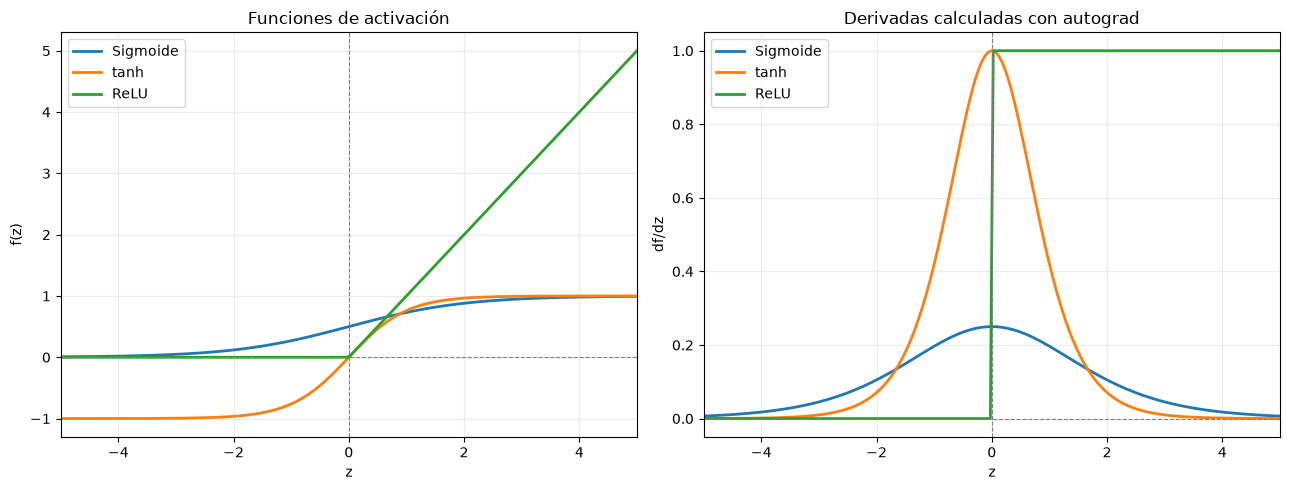

In [2]:
z_grafico = z.detach().numpy()
colores = {"Sigmoide": "tab:blue", "tanh": "tab:orange", "ReLU": "tab:green"}
fig, ejes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

for nombre in activaciones:
    ejes[0].plot(z_grafico, activaciones[nombre].detach().numpy(),
                 label=nombre, color=colores[nombre], linewidth=2)
    ejes[1].plot(z_grafico, derivadas[nombre].detach().numpy(),
                 label=nombre, color=colores[nombre], linewidth=2)

ejes[0].set(title="Funciones de activación", xlabel="z", ylabel="f(z)")
ejes[1].set(title="Derivadas calculadas con autograd", xlabel="z", ylabel="df/dz")
for eje in ejes:
    eje.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    eje.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    eje.set_xlim(-5, 5)
    eje.grid(alpha=0.25)
    eje.legend()
plt.tight_layout()
plt.show()

#### Interpretación de las funciones y sus derivadas

La gráfica muestra que la **sigmoide** produce valores entre 0 y 1 y se aplana hacia ambos extremos del intervalo. **`tanh`** produce valores entre -1 y 1, pasa por el origen y también se aplana para entradas de gran magnitud. **ReLU** devuelve cero para entradas negativas y crece linealmente para entradas positivas.

En el panel de derivadas, sigmoide y `tanh` tienen su mayor pendiente cerca de cero y derivadas cercanas a cero en los extremos. Esto corresponde a sus regiones de **saturación**: modificar la entrada produce muy poco cambio en la salida. ReLU presenta una derivada de 0 para $z < 0$ y de 1 para $z > 0$, por lo que su parte positiva no se satura.

Las derivadas se obtuvieron con `torch.autograd.grad` sobre un tensor de **200 puntos entre -5 y 5**, con `requires_grad=True`. Como cada salida depende únicamente de la entrada en su misma posición, derivar la suma de las salidas permite obtener las derivadas elemento a elemento.

### 2.2. Valores de referencia para interpretar las gráficas

Calcular también las derivadas en puntos específicos permite comparar el centro y los extremos del intervalo. La malla de 200 puntos no incluye exactamente cero, por lo que se evalúa por separado. ReLU no tiene derivada clásica en cero; el valor que devuelve autograd allí corresponde a la convención de PyTorch.

In [3]:
z_referencia = torch.tensor([-5., -2., -1., 0., 1., 2., 5.], requires_grad=True)
funciones_referencia = {
    "Sigmoide": torch.sigmoid,
    "tanh": torch.tanh,
    "ReLU": torch.relu,
}
derivadas_referencia = {}
for nombre, funcion in funciones_referencia.items():
    salida = funcion(z_referencia)
    derivadas_referencia[nombre] = torch.autograd.grad(salida.sum(), z_referencia)[0]

print(f"{'z':>6} {'Deriv. sigmoide':>18} {'Deriv. tanh':>16} {'Deriv. ReLU':>16}")
for i, valor in enumerate(z_referencia.detach().tolist()):
    print(f"{valor:6.1f}"
          f" {derivadas_referencia['Sigmoide'][i].item():18.6f}"
          f" {derivadas_referencia['tanh'][i].item():16.6f}"
          f" {derivadas_referencia['ReLU'][i].item():16.6f}")

     z    Deriv. sigmoide      Deriv. tanh      Deriv. ReLU
  -5.0           0.006648         0.000182         0.000000
  -2.0           0.104994         0.070651         0.000000
  -1.0           0.196612         0.419974         0.000000
   0.0           0.250000         1.000000         0.000000
   1.0           0.196612         0.419974         1.000000
   2.0           0.104994         0.070651         1.000000
   5.0           0.006648         0.000182         1.000000


#### Regiones donde se desvanece el gradiente

Los valores calculados confirman el comportamiento de las curvas:

| Punto de evaluación | Derivada de sigmoide | Derivada de `tanh` | Derivada de ReLU |
|---|---:|---:|---:|
| $z=-5$ | 0.006648 | 0.000182 | 0 |
| $z=0$ | 0.250000 | 1.000000 | 0 |
| $z=5$ | 0.006648 | 0.000182 | 1 |

La **sigmoide** tiene una derivada máxima de **0.25** en cero, pero en $z=\pm5$ disminuye a **0.006648**. Por tanto, el gradiente se atenúa especialmente para entradas muy negativas o muy positivas, cuando la salida está cerca de 0 o de 1.

En **`tanh`**, la derivada en cero es **1**, lo que permite transmitir mejor el gradiente local cerca del origen. Sin embargo, también se satura en ambos extremos: en $z=\pm5$ su derivada es apenas **0.000182**. Para esas entradas, su derivada es incluso menor que la de la sigmoide; usar `tanh` no elimina el problema de saturación.

Durante la retropropagación se multiplican las derivadas locales y los pesos de las capas por la regla de la cadena. Si varias activaciones aportan factores muy pequeños, el gradiente que llega a las primeras capas puede reducirse considerablemente y dificultar su aprendizaje. Estas gráficas ilustran ese mecanismo local; aquí no se entrenó una red profunda para medirlo directamente.

#### ¿Por qué ReLU es una opción habitual en capas ocultas?

Para entradas positivas, **ReLU mantiene una derivada de 1**, como muestran los valores en $z=1$, $z=2$ y $z=5$. En esa región, la activación no reduce el gradiente local ni se satura al aumentar la entrada. Estas propiedades la hacen una elección habitual para capas ocultas y ayudan a entrenar redes profundas.

Su limitación aparece en la región negativa, donde la salida y la derivada son cero. Si una neurona permanece en esa región para todos los ejemplos, puede dejar de recibir actualizaciones útiles a través de esa activación, fenómeno conocido como **neurona muerta**. Por ello, ReLU no garantiza por sí sola que desaparezcan todos los problemas de gradientes.

En **$z=0$**, ReLU no tiene derivada clásica porque las pendientes de sus dos lados son distintas. La tabla muestra que PyTorch utiliza **0** en ese punto como convención para autograd. El segmento que conecta las derivadas 0 y 1 en la gráfica es un efecto de unir los puntos muestreados; no significa que la derivada de ReLU cambie de forma gradual cerca de cero.

## Sección 3. Pérdida, optimizador y ciclo de entrenamiento

Entrenar una MLP sobre Iris, comparar tres tasas de aprendizaje de SGD con Adam y evaluar el mejor modelo en validación. El análisis se basa en las tablas y gráficas guardadas de esta ejecución.

Se requieren también `scikit-learn` y `pandas`. Si faltan en el kernel, descomenta la siguiente celda de instalación.

In [4]:
# %pip install scikit-learn pandas

In [5]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)

iris = load_iris()
X_train_iris, X_val_iris, y_train_iris, y_val_iris = train_test_split(
    iris.data, iris.target, test_size=0.2, stratify=iris.target, random_state=42
)

# Calcular las estadísticas solo con entrenamiento para evitar fuga de datos.
media_iris = X_train_iris.mean(axis=0)
desviacion_iris = X_train_iris.std(axis=0)
desviacion_iris = np.where(desviacion_iris == 0, 1.0, desviacion_iris)
X_train_iris = (X_train_iris - media_iris) / desviacion_iris
X_val_iris = (X_val_iris - media_iris) / desviacion_iris

X_train_t = torch.tensor(X_train_iris, dtype=torch.float32)
X_val_t = torch.tensor(X_val_iris, dtype=torch.float32)
y_train_t = torch.tensor(y_train_iris, dtype=torch.long)
y_val_t = torch.tensor(y_val_iris, dtype=torch.long)

print(f"Entrenamiento: {len(y_train_t)} ejemplos; validación: {len(y_val_t)} ejemplos")
display(pd.DataFrame({
    "Especie": iris.target_names,
    "Entrenamiento": np.bincount(y_train_iris, minlength=3),
    "Validación": np.bincount(y_val_iris, minlength=3),
}))
display(pd.DataFrame({
    "Característica": iris.feature_names,
    "Media usada": media_iris,
    "Desviación usada": desviacion_iris,
    "Media estandarizada (train)": X_train_iris.mean(axis=0),
    "Desviación estandarizada (train)": X_train_iris.std(axis=0),
}))

Entrenamiento: 120 ejemplos; validación: 30 ejemplos


,Especie,Entrenamiento,Validación
0,setosa,40,10
1,versicolor,40,10
2,virginica,40,10


,Característica,Media usada,Desviación usada,Media estandarizada (train),Desviación estandarizada (train)
0,sepal length (cm),5.841667,0.837415,-1.208293e-15,1.0
1,sepal width (cm),3.048333,0.446651,-2.036797e-15,1.0
2,petal length (cm),3.770000,1.761136,4.996004e-16,1.0
3,petal width (cm),1.205000,0.759479,1.674586e-15,1.0


#### Preparación del conjunto de datos

Iris se dividió en **120 ejemplos de entrenamiento (80%)** y **30 de validación (20%)**. La división estratificada conservó el balance entre clases: cada especie tiene **40 ejemplos de entrenamiento y 10 de validación**.

Las cuatro características se estandarizaron utilizando únicamente la media y la desviación del conjunto de entrenamiento. Las medias estandarizadas quedaron muy próximas a cero, con diferencias del orden de $10^{-15}$ debidas a la precisión numérica, y las desviaciones quedaron en **1**. Así, las características se presentan en escalas comparables. Aplicar esas mismas estadísticas a validación evita utilizar información de ese conjunto durante el cálculo de la transformación.

### 3.1. MLP y número de parámetros

La arquitectura tiene 4 entradas, una capa oculta de 16 neuronas con ReLU y 3 salidas, una por especie. La última capa entrega logits a `nn.CrossEntropyLoss`.

In [6]:
class MLPIris(nn.Module):
    def __init__(self):
        super().__init__()
        self.oculta = nn.Linear(4, 16)
        self.activacion = nn.ReLU()
        self.salida = nn.Linear(16, 3)

    def forward(self, x):
        return self.salida(self.activacion(self.oculta(x)))


torch.manual_seed(42)
modelo_base_iris = MLPIris()
estado_inicial_iris = copy.deepcopy(modelo_base_iris.state_dict())
print(modelo_base_iris)
display(pd.DataFrame([
    {"Tensor": nombre, "Forma": tuple(parametro.shape), "Parámetros": parametro.numel()}
    for nombre, parametro in modelo_base_iris.named_parameters()
]))
print("Total de parámetros:", sum(p.numel() for p in modelo_base_iris.parameters()))
print("Cálculo manual: (4 × 16 + 16) + (16 × 3 + 3) =", (4 * 16 + 16) + (16 * 3 + 3))

MLPIris(
  (oculta): Linear(in_features=4, out_features=16, bias=True)
  (activacion): ReLU()
  (salida): Linear(in_features=16, out_features=3, bias=True)
)


,Tensor,Forma,Parámetros
0,oculta.weight,"(16, 4)",64
1,oculta.bias,"(16,)",16
2,salida.weight,"(3, 16)",48
3,salida.bias,"(3,)",3


Total de parámetros: 131
Cálculo manual: (4 × 16 + 16) + (16 × 3 + 3) = 131


#### Arquitectura y uso de `CrossEntropyLoss`

La MLP **4 → 16 → 3** tiene **131 parámetros entrenables**: 64 pesos y 16 sesgos en la capa oculta, más 48 pesos y 3 sesgos en la salida. El conteo coincide con $(4\times16+16)+(16\times3+3)=131$. ReLU aporta la no linealidad y no agrega parámetros entrenables.

La salida entrega **tres logits**, uno por especie. No se aplica `softmax` antes de `nn.CrossEntropyLoss` porque esta pérdida ya combina internamente el cálculo de `log_softmax` con la pérdida logarítmica de la clase correcta.

Pasar probabilidades obtenidas con `softmax` haría que la pérdida las tratara como logits y volviera a normalizarlas, cambiando el objetivo esperado. Para clasificar basta con `argmax` sobre los logits, ya que `softmax` conserva su orden.

### 3.2. Ciclo de entrenamiento y tasas de aprendizaje

Cada experimento comienza con los mismos pesos y usa 500 épocas con el conjunto completo de entrenamiento por actualización. Se comparan las tasas **0.001, 0.1 y 10** de SGD. Se registran las pérdidas de entrenamiento y validación después de cada actualización.

Si una pérdida deja de ser finita, el entrenamiento se detiene y se reporta la época. La tasa alta se conserva como experimento aunque resulte inestable; su comportamiento se interpretará a partir de las salidas.

In [7]:
EPOCAS_IRIS = 500
criterio_iris = nn.CrossEntropyLoss()


def entrenar_iris(tipo_optimizador, tasa=None):
    modelo = MLPIris()
    modelo.load_state_dict(estado_inicial_iris)
    if tipo_optimizador == "SGD":
        optimizador = torch.optim.SGD(modelo.parameters(), lr=tasa)
    elif tipo_optimizador == "Adam":
        optimizador = torch.optim.Adam(modelo.parameters())  # Tasa por defecto.
    else:
        raise ValueError("Optimizador no reconocido")

    historial = {"epoca": [], "train_loss": [], "val_loss": []}
    estado = "Completado"
    for epoca in range(1, EPOCAS_IRIS + 1):
        modelo.train()
        optimizador.zero_grad()
        logits = modelo(X_train_t)              # 1. Forward.
        perdida = criterio_iris(logits, y_train_t)  # 2. Pérdida.
        if not torch.isfinite(perdida):
            estado = f"Pérdida no finita antes de actualizar en época {epoca}"
            break
        perdida.backward()                     # 3. Retropropagación.
        optimizador.step()                     # 4. Actualización de parámetros.

        modelo.eval()
        with torch.no_grad():
            perdida_train = criterio_iris(modelo(X_train_t), y_train_t).item()
            perdida_val = criterio_iris(modelo(X_val_t), y_val_t).item()
        historial["epoca"].append(epoca)
        historial["train_loss"].append(perdida_train)
        historial["val_loss"].append(perdida_val)
        if not np.isfinite([perdida_train, perdida_val]).all():
            estado = f"Pérdida no finita después de actualizar en época {epoca}"
            break

    modelo.eval()
    with torch.no_grad():
        logits_val = modelo(X_val_t)
        val_loss = criterio_iris(logits_val, y_val_t).item()
        # Una exactitud basada en logits no finitos no es interpretable.
        val_acc = ((logits_val.argmax(dim=1) == y_val_t).float().mean().item()
                   if torch.isfinite(logits_val).all() else float("nan"))
    return {
        "modelo": modelo, "historial": historial, "estado": estado,
        "lr": optimizador.param_groups[0]["lr"],
        "val_loss": val_loss, "val_acc": val_acc,
    }


experimentos_iris = {}
for tasa in [0.001, 0.1, 10.0]:
    nombre = f"SGD lr={tasa:g}"
    experimentos_iris[nombre] = entrenar_iris("SGD", tasa)
    print(nombre, "-", experimentos_iris[nombre]["estado"])


def tabla_experimentos_iris(experimentos):
    return pd.DataFrame([
        {"Experimento": nombre, "Tasa": datos["lr"],
         "Épocas registradas": len(datos["historial"]["epoca"]),
         "Pérdida train final": datos["historial"]["train_loss"][-1],
         "Pérdida val final": datos["val_loss"],
         "Exactitud val (%)": 100 * datos["val_acc"], "Estado": datos["estado"]}
        for nombre, datos in experimentos.items()
    ])


display(tabla_experimentos_iris(experimentos_iris))

SGD lr=0.001 - Completado
SGD lr=0.1 - Completado
SGD lr=10 - Completado


,Experimento,Tasa,Épocas registradas,Pérdida train final,Pérdida val final,Exactitud val (%),Estado
0,SGD lr=0.001,0.001,500,0.855164,0.867707,69.999999,Completado
1,SGD lr=0.1,0.100,500,0.066335,0.099068,93.333334,Completado
2,SGD lr=10,10.000,500,0.494751,0.524786,76.666665,Completado


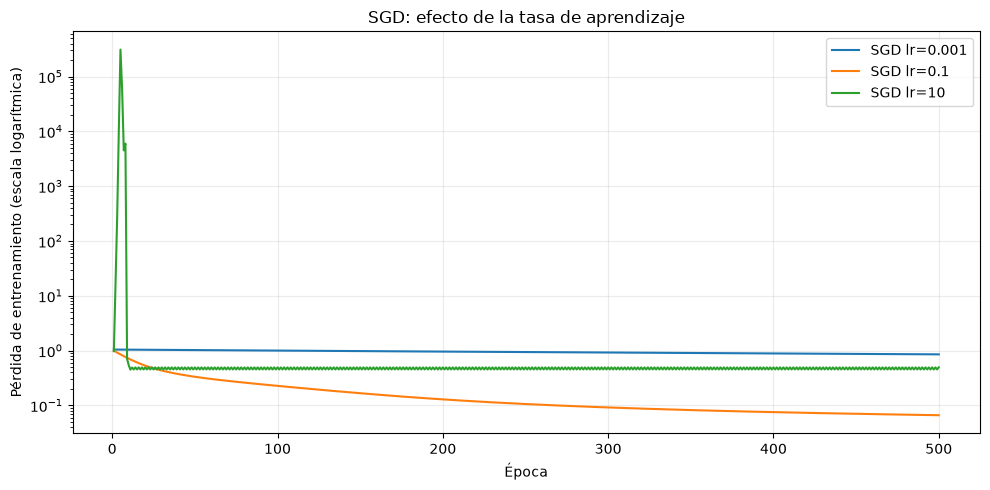

In [8]:
fig, eje = plt.subplots(figsize=(10, 5))
for nombre, datos in experimentos_iris.items():
    historial = datos["historial"]
    perdidas = np.asarray(historial["train_loss"])
    # No dibujar valores no finitos; la tabla anterior reporta la interrupción.
    eje.plot(historial["epoca"], np.where(np.isfinite(perdidas), perdidas, np.nan),
             label=nombre)
eje.set_yscale("log")
eje.set(title="SGD: efecto de la tasa de aprendizaje", xlabel="Época",
        ylabel="Pérdida de entrenamiento (escala logarítmica)")
eje.grid(alpha=0.25)
eje.legend()
plt.tight_layout()
plt.show()

#### Efecto de la tasa de aprendizaje en SGD

Los tres experimentos completaron **500 épocas** con la misma inicialización y el mismo conjunto de entrenamiento.

| Tasa de SGD | Pérdida final de entrenamiento | Pérdida final de validación | Exactitud en validación |
|---|---:|---:|---:|
| 0.001 | 0.855164 | 0.867707 | 70.00% |
| 0.1 | 0.066335 | 0.099068 | 93.33% |
| 10 | 0.494751 | 0.524786 | 76.67% |

Con **0.001**, la pérdida disminuye lentamente y permanece relativamente alta al terminar. Para este presupuesto de 500 actualizaciones, los pasos son demasiado pequeños para alcanzar el desempeño de las otras configuraciones. Esto no implica que nunca pueda mejorar con más entrenamiento.

Con **0.1**, la pérdida desciende de forma estable y alcanza el menor valor tanto en entrenamiento como en validación. Es la tasa que muestra la mejor convergencia entre las probadas y fue seleccionada por su pérdida final de validación de **0.099068**.

Con **10**, la gráfica muestra un aumento inicial de la pérdida por encima de $10^5$, seguido por una caída y oscilaciones persistentes alrededor de 0.5. Una tasa tan alta puede sobrepasar regiones de menor pérdida y provocar actualizaciones inestables. Sin embargo, **en esta ejecución no hubo divergencia sostenida ni pérdidas no finitas**: el entrenamiento terminó con pérdida 0.494751. El resultado observado es un pico inicial de inestabilidad y una solución final peor que la obtenida con 0.1. La escala logarítmica permite mostrar ese pico y las otras curvas en la misma figura.

El ciclo implementa explícitamente `zero_grad()`, el paso hacia adelante, el cálculo de la pérdida, `backward()` y `step()`. Limpiar los gradientes antes de cada actualización evita acumular los de épocas anteriores. Aunque se usa el optimizador `SGD`, cada actualización utiliza aquí los 120 ejemplos de entrenamiento, es decir, se trabaja con el lote completo.

### 3.3. Comparación de Adam con el mejor SGD

Se elige el mejor SGD por la **menor pérdida final de validación** entre las ejecuciones completadas con pérdidas finitas. Adam usa su tasa por defecto y parte de la misma inicialización. El criterio de selección del mejor modelo global será el mismo. La validación se utiliza para seleccionar modelos, por lo que su exactitud no sustituye una evaluación en un conjunto de prueba independiente.

Mejor SGD por pérdida final de validación: SGD lr=0.1
Tasa por defecto de Adam: 0.001


,Experimento,Tasa,Épocas registradas,Pérdida train final,Pérdida val final,Exactitud val (%),Estado
0,SGD lr=0.001,0.001,500,0.855164,0.867707,69.999999,Completado
1,SGD lr=0.1,0.100,500,0.066335,0.099068,93.333334,Completado
2,SGD lr=10,10.000,500,0.494751,0.524786,76.666665,Completado
3,Adam,0.001,500,0.124017,0.167858,93.333334,Completado


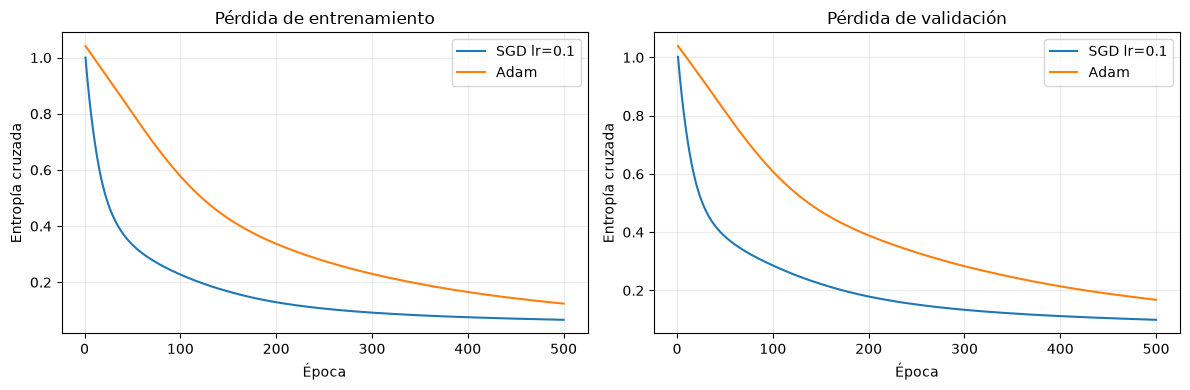

In [9]:
candidatos_sgd = {
    nombre: datos for nombre, datos in experimentos_iris.items()
    if datos["estado"] == "Completado" and np.isfinite(datos["val_loss"])
}
if not candidatos_sgd:
    raise RuntimeError("Ningún SGD terminó con pérdida finita; revisa las salidas.")
mejor_sgd_nombre = min(candidatos_sgd, key=lambda nombre: candidatos_sgd[nombre]["val_loss"])
experimentos_iris["Adam"] = entrenar_iris("Adam")
print("Mejor SGD por pérdida final de validación:", mejor_sgd_nombre)
print("Tasa por defecto de Adam:", experimentos_iris["Adam"]["lr"])
display(tabla_experimentos_iris(experimentos_iris))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for nombre in [mejor_sgd_nombre, "Adam"]:
    historial = experimentos_iris[nombre]["historial"]
    for eje, clave in zip(ejes, ["train_loss", "val_loss"]):
        perdidas = np.asarray(historial[clave])
        eje.plot(historial["epoca"], np.where(np.isfinite(perdidas), perdidas, np.nan),
                 label=nombre)
for eje, titulo in zip(ejes, ["Pérdida de entrenamiento", "Pérdida de validación"]):
    eje.set(title=titulo, xlabel="Época", ylabel="Entropía cruzada")
    eje.legend()
    eje.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Comparación entre Adam y el mejor SGD

Adam utilizó su tasa por defecto de **0.001**, los mismos pesos iniciales y las mismas **500 épocas** que SGD.

| Optimizador | Tasa | Pérdida final de entrenamiento | Pérdida final de validación | Exactitud en validación |
|---|---:|---:|---:|---:|
| SGD | 0.1 | 0.066335 | 0.099068 | 93.33% |
| Adam | 0.001 | 0.124017 | 0.167858 | 93.33% |

Las curvas muestran que **SGD con tasa 0.1 reduce la pérdida más rápido por época y termina con una pérdida menor** que Adam, tanto en entrenamiento como en validación. Ambas pérdidas de validación siguen descendiendo durante el experimento; no se observa un aumento sostenido que indique deterioro de la validación mientras mejora el entrenamiento.

Los dos modelos obtuvieron la misma exactitud, pero eso no implica que produzcan las mismas probabilidades ni que cometan exactamente los mismos errores. La exactitud solo cuenta aciertos, mientras que la entropía cruzada también considera la probabilidad asignada a la clase correcta. Por eso pueden coincidir en **93.33%** y tener pérdidas distintas.

Se eligió **SGD con tasa 0.1** porque tuvo la menor pérdida final de validación. Este resultado corresponde a estas tasas, arquitectura, división y número de épocas; no demuestra que SGD sea siempre superior a Adam. Además, se comparó la mejor de tres tasas de SGD con una sola configuración de Adam.

### 3.4. Evaluación del mejor modelo y matriz de confusión

Evaluar el modelo seleccionado con `model.eval()` y `torch.no_grad()`, mostrar sus predicciones e identificar el par de especies con más confusiones. Las filas de la matriz representan las clases reales y las columnas las predicciones.

Mejor modelo: SGD lr=0.1
Pérdida de validación: 0.099068
Exactitud de validación: 93.33%
Aciertos: 28 de 30


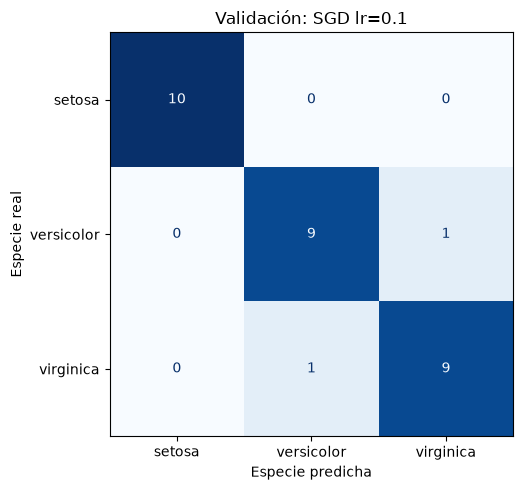

,Especie real,Predicción,Correcto
0,setosa,setosa,True
1,virginica,virginica,True
2,versicolor,versicolor,True
3,versicolor,versicolor,True
4,setosa,setosa,True
5,versicolor,versicolor,True
6,setosa,setosa,True
7,setosa,setosa,True
8,virginica,virginica,True
9,versicolor,versicolor,True


Par con más confusiones: versicolor / virginica (2 en ambas direcciones).


In [10]:
candidatos_iris = {
    nombre: datos for nombre, datos in experimentos_iris.items()
    if datos["estado"] == "Completado" and np.isfinite(datos["val_loss"])
}
mejor_nombre_iris = min(candidatos_iris, key=lambda nombre: candidatos_iris[nombre]["val_loss"])
mejor_modelo_iris = experimentos_iris[mejor_nombre_iris]["modelo"]
mejor_modelo_iris.eval()
with torch.no_grad():
    logits_finales_iris = mejor_modelo_iris(X_val_t)
    predicciones_iris = logits_finales_iris.argmax(dim=1)
    exactitud_iris = (predicciones_iris == y_val_t).float().mean().item()
    perdida_final_iris = criterio_iris(logits_finales_iris, y_val_t).item()

print("Mejor modelo:", mejor_nombre_iris)
print(f"Pérdida de validación: {perdida_final_iris:.6f}")
print(f"Exactitud de validación: {exactitud_iris:.2%}")
print(f"Aciertos: {(predicciones_iris == y_val_t).sum().item()} de {len(y_val_t)}")

matriz_iris = confusion_matrix(y_val_iris, predicciones_iris.numpy(), labels=[0, 1, 2])
fig, eje = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(matriz_iris, display_labels=iris.target_names).plot(
    ax=eje, cmap="Blues", values_format="d", colorbar=False
)
eje.set_title(f"Validación: {mejor_nombre_iris}")
eje.set_xlabel("Especie predicha")
eje.set_ylabel("Especie real")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "Especie real": iris.target_names[y_val_iris],
    "Predicción": iris.target_names[predicciones_iris.numpy()],
    "Correcto": predicciones_iris.numpy() == y_val_iris,
}))

confusiones_iris = {
    (iris.target_names[i], iris.target_names[j]): int(matriz_iris[i, j] + matriz_iris[j, i])
    for i in range(3) for j in range(i + 1, 3)
}
max_confusiones_iris = max(confusiones_iris.values())
if max_confusiones_iris == 0:
    print("No hubo confusiones en este conjunto de validación.")
else:
    for par, cantidad in confusiones_iris.items():
        if cantidad == max_confusiones_iris:
            print(f"Par con más confusiones: {par[0]} / {par[1]} ({cantidad} en ambas direcciones).")

#### Evaluación final y especies confundidas

El modelo seleccionado, **SGD con tasa 0.1**, obtuvo **28 aciertos de 30 ejemplos**, equivalentes a **93.33% de exactitud**, con una pérdida de validación de **0.099068**. La evaluación se realizó con `model.eval()` y `torch.no_grad()`: el primero establece el modo de evaluación y el segundo evita construir el grafo de gradientes durante las predicciones.

La matriz de confusión muestra:

- **Setosa:** 10 de 10 ejemplos clasificados correctamente.
- **Versicolor:** 9 de 10 correctos; un ejemplo se clasificó como virginica.
- **Virginica:** 9 de 10 correctos; un ejemplo se clasificó como versicolor.

El par con más confusiones es **versicolor / virginica**, con **dos errores en total, uno en cada dirección**. En esta partición, el modelo separó correctamente todos los ejemplos de setosa y tuvo dificultades únicamente entre las otras dos especies. Esto es compatible con una separación menos clara entre ellas en las características aprendidas, aunque la matriz por sí sola no identifica qué mediciones causaron los errores.

La validación también se utilizó para seleccionar el optimizador y la tasa. Por ello, el **93.33%** describe el rendimiento en este conjunto de selección de 30 ejemplos y no constituye una estimación basada en un conjunto de prueba independiente.

## Sección 4. Redes recurrentes para etiquetado POS

Entrenar un etiquetador con `Embedding → LSTM → Linear`, compararlo con una RNN y probar palabras ambiguas en oraciones propias. El análisis se basa en las salidas guardadas de esta ejecución.

Se trabaja en CPU. La primera ejecución requiere conexión para descargar `treebank` y `universal_tagset` de NLTK. Si falta NLTK en el kernel, descomenta la siguiente celda.

In [15]:
# %pip install nltk certifi

In [16]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
from IPython.display import display

SEMILLA_POS = 42
random.seed(SEMILLA_POS)
np.random.seed(SEMILLA_POS)
torch.manual_seed(SEMILLA_POS)

from pathlib import Path
import ssl
import certifi

# Admitir ejecutar el notebook desde Lab8 o desde la raíz del repositorio.
ruta_lab8 = Path.cwd() / "Lab8" if (Path.cwd() / "Lab8").is_dir() else Path.cwd()
ruta_nltk = ruta_lab8 / ".nltk_data"
ruta_nltk.mkdir(mode=0o700, exist_ok=True)
if str(ruta_nltk) not in nltk.data.path:
    nltk.data.path.insert(0, str(ruta_nltk))

recursos_nltk = {
    "treebank": "corpora/treebank",
    "universal_tagset": "taggers/universal_tagset",
}
for recurso, ubicacion in recursos_nltk.items():
    try:
        nltk.data.find(ubicacion)
        print(f"{recurso}: disponible localmente")
    except LookupError:
        # Usar certificados verificados; restaurar el contexto al terminar.
        contexto_original = ssl._create_default_https_context
        try:
            ssl._create_default_https_context = lambda: ssl.create_default_context(
                cafile=certifi.where()
            )
            nltk.download(recurso, download_dir=str(ruta_nltk),
                          quiet=False, raise_on_error=True)
        finally:
            ssl._create_default_https_context = contexto_original
        nltk.data.find(ubicacion)

oraciones_pos = list(nltk.corpus.treebank.tagged_sents(tagset="universal"))
train_pos, test_pos = train_test_split(oraciones_pos, test_size=0.2, random_state=SEMILLA_POS)

# El vocabulario se construye solo con entrenamiento; se normaliza a minúsculas.
PAD_PALABRA, UNK_PALABRA = 0, 1
palabras_train = sorted({palabra.lower() for oracion in train_pos for palabra, _ in oracion})
palabra_a_id = {"<PAD>": PAD_PALABRA, "<UNK>": UNK_PALABRA}
palabra_a_id.update({palabra: i + 2 for i, palabra in enumerate(palabras_train)})
# El relleno de etiquetas usa -100 y no es una clase predicha por el modelo.
PAD_ETIQUETA = -100
etiquetas_pos = sorted({etiqueta for oracion in train_pos for _, etiqueta in oracion})
etiqueta_a_id = {etiqueta: i for i, etiqueta in enumerate(etiquetas_pos)}
id_a_etiqueta = {i: etiqueta for etiqueta, i in etiqueta_a_id.items()}
assert all(etiqueta in etiqueta_a_id for oracion in test_pos for _, etiqueta in oracion)

tokens_test_pos = [palabra.lower() for oracion in test_pos for palabra, _ in oracion]
oov_test_pos = sum(palabra not in palabra_a_id for palabra in tokens_test_pos)
display(pd.DataFrame([
    {"Conjunto": nombre, "Oraciones": len(datos), "Tokens": sum(len(o) for o in datos)}
    for nombre, datos in [("Entrenamiento", train_pos), ("Prueba", test_pos)]
]))
print("Vocabulario (incluye PAD y UNK):", len(palabra_a_id))
print("Etiquetas:", etiquetas_pos)
print(f"Tokens desconocidos en prueba: {oov_test_pos}/{len(tokens_test_pos)} "
      f"({oov_test_pos / len(tokens_test_pos):.2%})")
print("Ejemplo de entrenamiento:", train_pos[0])

treebank: disponible localmente
universal_tagset: disponible localmente


,Conjunto,Oraciones,Tokens
0,Entrenamiento,3131,80127
1,Prueba,783,20549


Vocabulario (incluye PAD y UNK): 10140
Etiquetas: ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']
Tokens desconocidos en prueba: 1345/20549 (6.55%)
Ejemplo de entrenamiento: [('Pierre', 'NOUN'), ('Vinken', 'NOUN'), (',', '.'), ('61', 'NUM'), ('years', 'NOUN'), ('old', 'ADJ'), (',', '.'), ('will', 'VERB'), ('join', 'VERB'), ('the', 'DET'), ('board', 'NOUN'), ('as', 'ADP'), ('a', 'DET'), ('nonexecutive', 'ADJ'), ('director', 'NOUN'), ('Nov.', 'NOUN'), ('29', 'NUM'), ('.', '.')]


#### Corpus, vocabulario y palabras desconocidas

Las **3,914 oraciones** de Treebank se dividieron en **3,131 de entrenamiento**, con **80,127 tokens**, y **783 de prueba**, con **20,549 tokens**. La división se hizo por oraciones completas, por lo que una misma oración no aporta tokens a ambos conjuntos.

El vocabulario construido únicamente con entrenamiento contiene **10,140 entradas**, incluidos `<PAD>` y `<UNK>`, y se predicen **12 etiquetas universales**. Las palabras se normalizaron a minúsculas, lo que reduce variantes del vocabulario, aunque también elimina información de capitalización.

En prueba aparecen **1,345 tokens desconocidos**, equivalentes al **6.55%**. Todos se representan con `<UNK>`: el modelo puede usar su contexto, pero no distinguir sus formas mediante embeddings individuales. Esta proporción permite interpretar por separado el desempeño sobre palabras conocidas y nuevas.

### 4.1. Batches y relleno

Las oraciones se dividen completas entre entrenamiento y prueba. Cada batch se rellena hasta la longitud de su oración más larga con `pad_sequence`. Las palabras nuevas reciben `<UNK>`; las etiquetas de relleno reciben -100 para excluirlas de la pérdida y de la exactitud.

Durante el entrenamiento se sustituye aleatoriamente el 5% de las palabras reales por `<UNK>` para que su embedding reciba actualizaciones. Las etiquetas se conservan. Esta sustitución no se aplica al evaluar.

In [17]:
def codificar_pos(oracion):
    palabras = torch.tensor([palabra_a_id.get(p.lower(), UNK_PALABRA) for p, _ in oracion],
                            dtype=torch.long)
    etiquetas = torch.tensor([etiqueta_a_id[e] for _, e in oracion], dtype=torch.long)
    return palabras, etiquetas


def crear_batch_pos(batch):
    palabras, etiquetas = zip(*batch)
    longitudes = torch.tensor([len(p) for p in palabras], dtype=torch.long)
    return (pad_sequence(palabras, batch_first=True, padding_value=PAD_PALABRA),
            pad_sequence(etiquetas, batch_first=True, padding_value=PAD_ETIQUETA),
            longitudes)


dataset_train_pos = [codificar_pos(o) for o in train_pos]
dataset_test_pos = [codificar_pos(o) for o in test_pos]
loader_test_pos = DataLoader(dataset_test_pos, batch_size=32, shuffle=False,
                            collate_fn=crear_batch_pos, num_workers=0)

palabras_batch, etiquetas_batch, longitudes_batch = crear_batch_pos(dataset_train_pos[:4])
print("Forma del batch de palabras:", tuple(palabras_batch.shape))
print("Forma del batch de etiquetas:", tuple(etiquetas_batch.shape))
print("Longitudes reales:", longitudes_batch.tolist())
print("Tokens reales:", (etiquetas_batch != PAD_ETIQUETA).sum().item())
print("Posiciones de relleno:", (etiquetas_batch == PAD_ETIQUETA).sum().item())

Forma del batch de palabras: (4, 41)
Forma del batch de etiquetas: (4, 41)
Longitudes reales: [18, 5, 41, 18]
Tokens reales: 82
Posiciones de relleno: 82


#### Tratamiento del relleno

El batch de ejemplo tiene forma **(4, 41)** porque contiene cuatro oraciones y la más larga tiene 41 tokens. Sus longitudes reales son **18, 5, 41 y 18**, que suman **82 tokens**. Las otras **82 posiciones** son relleno.

El relleno permite procesar juntas oraciones de distintas longitudes, pero no representa palabras que deban aprenderse o evaluarse. Por eso, `ignore_index=-100` lo excluye de la pérdida y una máscara lo excluye del cálculo de exactitud. Además, las secuencias empaquetadas evitan que la recurrencia procese esas posiciones, algo especialmente útil en la dirección inversa de los modelos bidireccionales.

### 4.2. Modelos LSTM y RNN

Ambas redes usan embeddings de 64 dimensiones y 64 unidades ocultas por dirección. Se emplean capas recurrentes **bidireccionales** para aprovechar tanto las palabras anteriores como las posteriores al etiquetar cada token. La capa de salida recibe 128 características por token.

`pack_padded_sequence` evita procesar el relleno dentro de las recurrencias; después se recupera el batch con `pad_packed_sequence`. Se mantienen las mismas dimensiones en LSTM y RNN, aunque la LSTM tiene más parámetros por sus compuertas.

In [18]:
class EtiquetadorPOS(nn.Module):
    def __init__(self, tipo="LSTM"):
        super().__init__()
        self.embedding = nn.Embedding(len(palabra_a_id), 64, padding_idx=PAD_PALABRA)
        if tipo == "LSTM":
            self.recurrente = nn.LSTM(64, 64, batch_first=True, bidirectional=True)
        elif tipo == "RNN":
            self.recurrente = nn.RNN(64, 64, batch_first=True, bidirectional=True)
        else:
            raise ValueError("Usa LSTM o RNN")
        self.salida = nn.Linear(128, len(etiqueta_a_id))

    def forward(self, palabras, longitudes):
        embeddings = self.embedding(palabras)
        secuencias = pack_padded_sequence(embeddings, longitudes.cpu(), batch_first=True,
                                         enforce_sorted=False)
        salida_empaquetada, _ = self.recurrente(secuencias)
        salida, _ = pad_packed_sequence(salida_empaquetada, batch_first=True,
                                        total_length=palabras.size(1))
        return self.salida(salida)


for tipo in ["LSTM", "RNN"]:
    torch.manual_seed(SEMILLA_POS)
    modelo_demo_pos = EtiquetadorPOS(tipo)
    print(f"\n{tipo}: {sum(p.numel() for p in modelo_demo_pos.parameters()):,} parámetros")
    print(modelo_demo_pos)
    with torch.no_grad():
        print("Forma de salida:", tuple(modelo_demo_pos(palabras_batch, longitudes_batch).shape))


LSTM: 717,068 parámetros
EtiquetadorPOS(
  (embedding): Embedding(10140, 64, padding_idx=0)
  (recurrente): LSTM(64, 64, batch_first=True, bidirectional=True)
  (salida): Linear(in_features=128, out_features=12, bias=True)
)
Forma de salida: (4, 41, 12)

RNN: 667,148 parámetros
EtiquetadorPOS(
  (embedding): Embedding(10140, 64, padding_idx=0)
  (recurrente): RNN(64, 64, batch_first=True, bidirectional=True)
  (salida): Linear(in_features=128, out_features=12, bias=True)
)
Forma de salida: (4, 41, 12)


#### Arquitecturas construidas

Ambos modelos transforman cada palabra en un embedding de **64 dimensiones**, procesan la oración en ambas direcciones y producen **12 logits por token**. La salida del batch de ejemplo tiene forma **(4, 41, 12)**: cuatro oraciones, 41 posiciones y 12 posibles etiquetas.

La LSTM tiene **717,068 parámetros** y la RNN **667,148**, una diferencia de **49,920 parámetros**. Las dimensiones de los embeddings y de los estados ocultos son iguales, pero la LSTM incorpora compuertas y un estado de celda para regular qué información conserva y transmite. La RNN utiliza una actualización recurrente más simple.

La bidireccionalidad permite aprovechar palabras anteriores y posteriores, lo que resulta apropiado cuando se dispone de la oración completa para etiquetarla. La comparación mantiene las dimensiones y el procedimiento de entrenamiento, pero no iguala el número total de parámetros.

### 4.3. Entrenamiento y evaluación por token

Se entrenan ambos modelos durante **8 épocas**, con batches de 32 oraciones, Adam con tasa 0.001 y recorte de la norma del gradiente a 5. Se reinician las semillas para cada modelo, incluido el generador que mezcla los batches. Los embeddings iniciales coinciden; las capas recurrentes tienen estructuras diferentes.

La pérdida ignora el relleno con `ignore_index=-100`. La prueba se evalúa al terminar el entrenamiento, sin ajustar el número de épocas según sus resultados. También se reporta la exactitud por separado para palabras conocidas y desconocidas.

In [19]:
EPOCAS_POS = 8


def evaluar_pos(modelo, loader):
    modelo.eval()
    aciertos = total = aciertos_oov = total_oov = 0
    perdida_total = 0.0
    criterio_suma = nn.CrossEntropyLoss(ignore_index=PAD_ETIQUETA, reduction="sum")
    with torch.no_grad():
        for palabras, etiquetas, longitudes in loader:
            logits = modelo(palabras, longitudes)
            perdida_total += criterio_suma(logits.reshape(-1, len(etiqueta_a_id)),
                                          etiquetas.reshape(-1)).item()
            mascara = etiquetas != PAD_ETIQUETA
            correctos = (logits.argmax(dim=-1) == etiquetas) & mascara
            mascara_oov = (palabras == UNK_PALABRA) & mascara
            aciertos += correctos.sum().item()
            total += mascara.sum().item()
            aciertos_oov += (correctos & mascara_oov).sum().item()
            total_oov += mascara_oov.sum().item()
    return {"perdida": perdida_total / total, "exactitud": aciertos / total,
            "tokens": total, "aciertos": aciertos, "tokens_oov": total_oov,
            "exactitud_oov": aciertos_oov / total_oov if total_oov else float("nan"),
            "exactitud_conocidas": ((aciertos - aciertos_oov) / (total - total_oov)
                                     if total > total_oov else float("nan"))}


def entrenar_pos(tipo):
    torch.manual_seed(SEMILLA_POS)
    random.seed(SEMILLA_POS)
    np.random.seed(SEMILLA_POS)
    generador = torch.Generator().manual_seed(SEMILLA_POS)
    generador_unk = torch.Generator().manual_seed(SEMILLA_POS + 1)
    loader = DataLoader(dataset_train_pos, batch_size=32, shuffle=True,
                        collate_fn=crear_batch_pos, generator=generador, num_workers=0)
    modelo = EtiquetadorPOS(tipo)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)
    criterio = nn.CrossEntropyLoss(ignore_index=PAD_ETIQUETA)
    historial = []
    inicio = time.perf_counter()
    for epoca in range(1, EPOCAS_POS + 1):
        modelo.train()
        suma_perdida = total_tokens = 0
        for palabras, etiquetas, longitudes in loader:
            entradas = palabras.clone()
            reemplazos = (torch.rand(palabras.shape, generator=generador_unk) < 0.05)
            reemplazos &= palabras != PAD_PALABRA
            entradas[reemplazos] = UNK_PALABRA
            optimizador.zero_grad()
            logits = modelo(entradas, longitudes)
            perdida = criterio(logits.reshape(-1, len(etiqueta_a_id)), etiquetas.reshape(-1))
            if not torch.isfinite(perdida):
                raise RuntimeError(f"Pérdida no finita en {tipo}, época {epoca}")
            perdida.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=5.0)
            optimizador.step()
            cantidad = (etiquetas != PAD_ETIQUETA).sum().item()
            suma_perdida += perdida.item() * cantidad
            total_tokens += cantidad
        historial.append(suma_perdida / total_tokens)
        print(f"{tipo} | época {epoca}/{EPOCAS_POS} | pérdida train: {historial[-1]:.4f}",
              flush=True)
    segundos = time.perf_counter() - inicio
    metricas = evaluar_pos(modelo, loader_test_pos)
    return {"modelo": modelo, "historial": historial, "metricas": metricas,
            "segundos": segundos, "parametros": sum(p.numel() for p in modelo.parameters())}


resultados_pos = {}
for tipo in ["LSTM", "RNN"]:
    resultados_pos[tipo] = entrenar_pos(tipo)
    print(f"{tipo} | exactitud en prueba: {resultados_pos[tipo]['metricas']['exactitud']:.2%}\n")

LSTM | época 1/8 | pérdida train: 1.6534
LSTM | época 2/8 | pérdida train: 0.7993
LSTM | época 3/8 | pérdida train: 0.5685
LSTM | época 4/8 | pérdida train: 0.4568
LSTM | época 5/8 | pérdida train: 0.3838
LSTM | época 6/8 | pérdida train: 0.3293
LSTM | época 7/8 | pérdida train: 0.2879
LSTM | época 8/8 | pérdida train: 0.2530
LSTM | exactitud en prueba: 92.44%

RNN | época 1/8 | pérdida train: 1.4386
RNN | época 2/8 | pérdida train: 0.7910
RNN | época 3/8 | pérdida train: 0.6047
RNN | época 4/8 | pérdida train: 0.5038
RNN | época 5/8 | pérdida train: 0.4328
RNN | época 6/8 | pérdida train: 0.3781
RNN | época 7/8 | pérdida train: 0.3361
RNN | época 8/8 | pérdida train: 0.3001
RNN | exactitud en prueba: 91.43%



,Modelo,Parámetros,Pérdida prueba,Exactitud prueba (%),Exactitud conocidas (%),Exactitud OOV (%),Tokens prueba,Tokens OOV,Tiempo entrenamiento (s)
0,LSTM,717068,0.247413,92.437588,94.209540,67.137546,20549,1345,12.207559
1,RNN,667148,0.281117,91.425373,93.084774,67.732342,20549,1345,7.672757


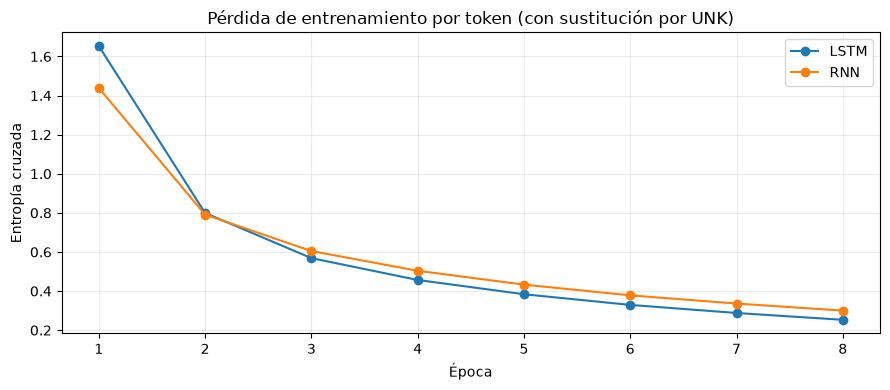

In [20]:
tabla_pos_modelos = pd.DataFrame([
    {"Modelo": tipo, "Parámetros": datos["parametros"],
     "Pérdida prueba": datos["metricas"]["perdida"],
     "Exactitud prueba (%)": 100 * datos["metricas"]["exactitud"],
     "Exactitud conocidas (%)": 100 * datos["metricas"]["exactitud_conocidas"],
     "Exactitud OOV (%)": 100 * datos["metricas"]["exactitud_oov"],
     "Tokens prueba": datos["metricas"]["tokens"],
     "Tokens OOV": datos["metricas"]["tokens_oov"],
     "Tiempo entrenamiento (s)": datos["segundos"]}
    for tipo, datos in resultados_pos.items()
])
display(tabla_pos_modelos)

fig, eje = plt.subplots(figsize=(9, 4))
for tipo, datos in resultados_pos.items():
    eje.plot(range(1, EPOCAS_POS + 1), datos["historial"], marker="o", label=tipo)
eje.set(title="Pérdida de entrenamiento por token (con sustitución por UNK)",
        xlabel="Época", ylabel="Entropía cruzada")
eje.legend()
eje.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Resultados de LSTM y RNN

Los dos modelos redujeron su pérdida durante las **8 épocas**. La RNN comenzó con una pérdida menor, pero desde la tercera época la LSTM obtuvo valores inferiores. La pérdida final de entrenamiento fue **0.2530** para LSTM y **0.3001** para RNN. Estas curvas incluyen la sustitución aleatoria del 5% de las palabras por `<UNK>` durante el entrenamiento.

| Modelo | Pérdida en prueba | Exactitud global | Exactitud en conocidas | Exactitud en OOV | Tiempo de entrenamiento |
|---|---:|---:|---:|---:|---:|
| LSTM | 0.247413 | 92.44% | 94.21% | 67.14% | 12.21 s |
| RNN | 0.281117 | 91.43% | 93.08% | 67.73% | 7.67 s |

La **LSTM obtuvo la mayor exactitud global**, con una ventaja de aproximadamente **1.01 puntos porcentuales**, y también la menor pérdida en prueba. Esto es compatible con una mejor representación del contexto mediante su estado de celda y sus compuertas, pero una sola ejecución no permite atribuir toda la diferencia a ese mecanismo: también tiene más parámetros. La RNN requirió menos tiempo en esta ejecución; esos tiempos dependen del equipo y de las condiciones de ejecución.

La ventaja de LSTM no se mantiene en las palabras desconocidas: la RNN obtuvo **67.73%**, frente a **67.14%** de LSTM. En ambos casos existe una caída importante respecto a las palabras conocidas. El contexto ayuda a etiquetar `<UNK>`, pero compartir un único embedding impide aprovechar diferencias de forma, como prefijos o sufijos. La sustitución por `<UNK>` durante el entrenamiento permite aprender esa representación, aunque aquí no se realizó un experimento sin sustitución para medir su beneficio.

Una posible mejora sería representar también caracteres o subpalabras, para extraer información morfológica de palabras nuevas. Las curvas muestran aprendizaje en entrenamiento, pero sin una curva de validación por época no bastan para establecer si más épocas mejorarían la generalización. La exactitud de prueba se calculó sobre los **20,549 tokens reales**, sin contar el relleno.

### 4.4. Palabras ambiguas en contexto

Se usa el modelo con mayor exactitud observada en prueba para los ejemplos solicitados. Esta elección es descriptiva y no implica que su puntuación sea una nueva evaluación independiente. Se muestran todos los tokens, las palabras desconocidas y la etiqueta esperada de la palabra ambigua; no se presupone que el modelo vaya a resolver todos los casos.

In [21]:
mejor_tipo_pos = max(resultados_pos, key=lambda tipo: resultados_pos[tipo]["metricas"]["exactitud"])
mejor_modelo_pos = resultados_pos[mejor_tipo_pos]["modelo"]
mejor_modelo_pos.eval()
print("Modelo usado para los ejemplos:", mejor_tipo_pos)

# Oraciones propias ya tokenizadas para mantener separada la puntuación.
ejemplos_ambiguos_pos = [
    (["They", "book", "a", "flight", "."], "book", "VERB"),
    (["The", "book", "is", "on", "the", "table", "."], "book", "NOUN"),
    (["They", "run", "every", "morning", "."], "run", "VERB"),
    (["The", "run", "was", "long", "."], "run", "NOUN"),
]
resumen_ambiguos_pos = []
for tokens, ambigua, esperada in ejemplos_ambiguos_pos:
    ids = torch.tensor([[palabra_a_id.get(t.lower(), UNK_PALABRA) for t in tokens]],
                       dtype=torch.long)
    with torch.no_grad():
        pred = mejor_modelo_pos(ids, torch.tensor([len(tokens)])).argmax(dim=-1)[0].tolist()
    etiquetas = [id_a_etiqueta[i] for i in pred]
    print("\nOración:", " ".join(tokens))
    display(pd.DataFrame({"Token": tokens, "POS predicho": etiquetas,
                          "OOV": [t.lower() not in palabra_a_id for t in tokens]}))
    indice = tokens.index(ambigua)
    resumen_ambiguos_pos.append({"Oración": " ".join(tokens), "Palabra": ambigua,
                                 "Esperada": esperada, "Predicha": etiquetas[indice],
                                 "Correcta": etiquetas[indice] == esperada,
                                 "OOV": ambigua.lower() not in palabra_a_id})
display(pd.DataFrame(resumen_ambiguos_pos))

Modelo usado para los ejemplos: LSTM

Oración: They book a flight .


,Token,POS predicho,OOV
0,They,PRON,False
1,book,VERB,False
2,a,DET,False
3,flight,NOUN,True
4,.,.,False



Oración: The book is on the table .


,Token,POS predicho,OOV
0,The,DET,False
1,book,NOUN,False
2,is,VERB,False
3,on,ADP,False
4,the,DET,False
5,table,NOUN,False
6,.,.,False



Oración: They run every morning .


,Token,POS predicho,OOV
0,They,PRON,False
1,run,VERB,False
2,every,VERB,False
3,morning,NOUN,False
4,.,.,False



Oración: The run was long .


,Token,POS predicho,OOV
0,The,DET,False
1,run,NOUN,False
2,was,VERB,False
3,long,ADV,False
4,.,.,False


,Oración,Palabra,Esperada,Predicha,Correcta,OOV
0,They book a flight .,book,VERB,VERB,True,False
1,The book is on the table .,book,NOUN,NOUN,True,False
2,They run every morning .,run,VERB,VERB,True,False
3,The run was long .,run,NOUN,NOUN,True,False


#### ¿Resuelve el contexto la ambigüedad?

Se utilizó la LSTM por su mayor exactitud observada en prueba. En los cuatro ejemplos, identificó correctamente la categoría de la palabra ambigua:

| Oración | Palabra | Etiqueta esperada | Etiqueta predicha |
|---|---|---|---|
| They book a flight. | book | VERB | VERB |
| The book is on the table. | book | NOUN | NOUN |
| They run every morning. | run | VERB | VERB |
| The run was long. | run | NOUN | NOUN |

Tanto `book` como `run` estaban en el vocabulario. Aunque cada palabra recibe el mismo embedding inicial en sus dos usos, el estado recurrente depende de la oración. Así, el modelo puede asignarles etiquetas distintas según su contexto, como ocurre con la ambigüedad de “vino” discutida en clase. Estos ejemplos muestran que la LSTM resolvió los **cuatro casos seleccionados**, sin demostrar que resuelva toda ambigüedad posible.

Las oraciones completas sí contienen errores: en “They run every morning”, `every` se etiquetó como **VERB**, aunque funciona como **DET**; en “The run was long”, `long` se etiquetó como **ADV**, aunque funciona como **ADJ**. Por tanto, acertar la palabra objetivo no significa etiquetar correctamente toda la oración.

Además, `flight` era desconocida y fue etiquetada como **NOUN**, de forma correcta en ese contexto. Este caso ilustra que el modelo puede apoyarse en las palabras circundantes aun sin disponer de un embedding específico para la palabra nueva.

### 4.5. Comparación con el Laboratorio 6

En `Lab6/lab6.ipynb`, spaCy `en_core_web_sm` coincidió con la anotación manual en **120 de 123 tokens (97.56%)** de cinco oraciones de *Pride and Prejudice*. Esa evaluación utilizó etiquetas finas Penn e incluyó los tokens producidos por spaCy.

Aquí se evalúan etiquetas universales de NLTK sobre oraciones de Treebank, con su propia tokenización y sin contar el relleno. Las cifras se presentan como referencia histórica: al cambiar corpus, tamaño de muestra y etiquetas, su diferencia no permite atribuir directamente una ventaja a una arquitectura. Los embeddings de estos modelos se aprenden desde cero; la comparación con spaCy deberá considerar también el entrenamiento previo de ese sistema.

In [22]:
comparacion_lab6_pos = pd.DataFrame([
    {"Modelo": "spaCy en_core_web_sm (Lab 6)", "Exactitud / coincidencia (%)": 120 / 123 * 100,
     "Tokens evaluados": 123, "Corpus": "5 oraciones de Pride and Prejudice",
     "Etiquetas": "Penn (anotación manual)"},
    *[{"Modelo": tipo + " (Lab 8)",
       "Exactitud / coincidencia (%)": datos["metricas"]["exactitud"] * 100,
       "Tokens evaluados": datos["metricas"]["tokens"], "Corpus": "Treebank, 20% de prueba",
       "Etiquetas": "Universales NLTK"}
      for tipo, datos in resultados_pos.items()]
])
display(comparacion_lab6_pos)
print("Referencia histórica: las métricas provienen de conjuntos y etiquetas diferentes.")

,Modelo,Exactitud / coincidencia (%),Tokens evaluados,Corpus,Etiquetas
0,spaCy en_core_web_sm (Lab 6),97.560976,123,5 oraciones de Pride and Prejudice,Penn (anotación manual)
1,LSTM (Lab 8),92.437588,20549,"Treebank, 20% de prueba",Universales NLTK
2,RNN (Lab 8),91.425373,20549,"Treebank, 20% de prueba",Universales NLTK


Referencia histórica: las métricas provienen de conjuntos y etiquetas diferentes.


#### Comparación con spaCy en el Laboratorio 6

La coincidencia de spaCy con la anotación manual del Lab 6 fue **97.56%**, frente a **92.44%** de la LSTM y **91.43%** de la RNN en esta sección. Las diferencias numéricas son aproximadamente **5.12** y **6.14 puntos porcentuales**, respectivamente, pero las condiciones de evaluación son distintas.

En el Lab 6 se revisaron **123 tokens de cinco oraciones de una novela**, usando etiquetas finas Penn. Aquí se evaluaron **20,549 tokens de Treebank** con 12 etiquetas universales y otra tokenización. El tamaño de muestra, el dominio y el inventario de etiquetas cambian, de modo que estas cifras no permiten concluir directamente que una arquitectura sea superior.

Los modelos de esta sección aprendieron sus embeddings desde cero con **80,127 tokens de entrenamiento** durante ocho épocas, mientras que spaCy se utilizó como un sistema previamente entrenado. El volumen y la variedad de los datos de entrenamiento, la calidad de las representaciones léxicas y la arquitectura son factores que podrían explicar diferencias de desempeño, pero no se aislaron experimentalmente aquí. En particular, el bajo desempeño relativo sobre OOV evidencia una limitación de nuestros embeddings por palabra.

Para comparar los sistemas de manera más directa habría que evaluarlos sobre los mismos tokens, con las mismas etiquetas y un conjunto de referencia común. La comparación actual permite relacionar la observación de ambigüedad contextual del Lab 6 con el comportamiento de las redes entrenadas en esta sección.

## 9. Conclusiones: del perceptrón a la atención

### Importancia de XOR

El caso XOR fue importante en la historia de las redes neuronales porque mostró una limitación fundamental del perceptrón de una sola capa: no puede resolver problemas cuyas clases no son linealmente separables. En XOR, los puntos de una misma clase ocupan esquinas opuestas, por lo que ninguna recta separa correctamente las dos clases. Su solución requiere, dentro de la arquitectura estudiada, **ambos ingredientes: una capa oculta y una activación no lineal entre las capas**. Apilar capas lineales sin activación sigue siendo equivalente a una sola transformación afín; aplicar únicamente una activación de umbral a una salida lineal tampoco cambia la geometría de su frontera de decisión. La capa oculta con `tanh` permite construir una representación que la capa final sí puede separar. En este laboratorio, la MLP con `tanh` alcanzó **100% de exactitud**, mientras que la versión sin activación intermedia terminó con **50%**, ilustrando la importancia de la no linealidad junto con la profundidad.

### One-hot, bag-of-words, TF-IDF y embeddings

Una representación **one-hot** identifica cada palabra mediante un vector del tamaño del vocabulario, con un único 1 y el resto de posiciones en 0. No expresa por sí sola semejanza entre palabras: dos palabras distintas ocupan posiciones diferentes aunque tengan significados o funciones parecidos. **Bag-of-words** representa un documento mediante conteos de términos, y **TF-IDF** pondera esos términos según su frecuencia en el documento y su presencia en el corpus. En sus versiones por unigramas, ambas representaciones pierden el orden de las palabras y suelen producir vectores dispersos de gran dimensión. One-hot representa aquí un token, mientras que bag-of-words y TF-IDF resumen un documento; comparten un vocabulario de referencia, pero cumplen funciones distintas.

Los **embeddings densos** asignan a cada palabra un vector compacto cuyos valores se aprenden durante el entrenamiento. Esto permite compartir características entre palabras y aprender relaciones útiles para la tarea, en lugar de tratarlas solo como identificadores independientes. En nuestro modelo, cada palabra se representa con **64 valores**, frente a las **10,140 posiciones** que requeriría un vector one-hot explícito. `nn.Embedding` obtiene ese vector mediante una consulta por índice, sin construir el one-hot. La LSTM procesa después la secuencia de embeddings y aprovecha el orden y el contexto para etiquetar cada token. Los embeddings por palabra no incorporan por sí solos ese contexto: es la red recurrente la que lo integra. Además, una menor dimensión por token no significa que desaparezca el costo del vocabulario, pues se almacena una matriz de embeddings con una fila por entrada.

Usar embeddings densos **no resuelve automáticamente el problema OOV**. Si una palabra no pertenece al vocabulario, no tiene una fila propia en la matriz. Del mismo modo, un vocabulario fijo de one-hot, bag-of-words o TF-IDF necesita una política para términos nuevos, como ignorarlos o asignarles un símbolo especial. Un cambio de dominio puede introducir más palabras desconocidas y también usos nuevos de palabras conocidas; estos últimos no son OOV en sentido estricto. Las representaciones por subpalabras o caracteres permiten aprovechar partes conocidas de términos nuevos y reducen la dependencia de un vocabulario de palabras completas.

### Palabras desconocidas en nuestra LSTM y una mejora posible

La LSTM convierte cada palabra a minúsculas y busca su índice en el vocabulario construido solo con entrenamiento. Si no aparece, utiliza **`<UNK>`**, cuyo índice es **1**; el relleno usa **`<PAD>`**, con índice **0**, y se excluye de la pérdida y de la evaluación. Durante el entrenamiento se sustituye aleatoriamente el **5% de las palabras reales** por `<UNK>` para que su embedding reciba actualizaciones y el modelo aprenda a usar el contexto cuando falta la identidad de una palabra. Como la LSTM es bidireccional, puede apoyarse tanto en las palabras anteriores como en las posteriores.

En prueba hubo **1,345 tokens OOV de 20,549**, equivalentes al **6.55%**. La LSTM obtuvo **67.14% de exactitud en OOV**, frente a **94.21% en palabras conocidas**. Esto muestra que el contexto permite recuperar parte de la información, pero el símbolo compartido pierde diferencias entre las palabras desconocidas. Por ejemplo, etiquetó correctamente `flight` como sustantivo en “They book a flight”, aunque esa palabra no estaba en el vocabulario.

Una mejora concreta sería **añadir un codificador de caracteres**, como una CNN o una LSTM pequeña, y concatenar su salida con el embedding de cada palabra antes de la LSTM de la oración. Así, incluso una palabra OOV tendría una representación basada en su escritura, incluidos prefijos y sufijos, en lugar de depender únicamente del mismo vector `<UNK>`. Para comprobar la mejora, se podría reservar una parte del entrenamiento para validación, ajustar allí la configuración y comparar al final la exactitud global y la exactitud OOV sobre el mismo conjunto de prueba, manteniendo fijo el resto del procedimiento.
